In [18]:
!pip install librosa

## Model — MFCC-Based Audio Classification

📁 Dataset Description

We are using the UrbanSound8K, which contains labeled urban audio clips (≤4 seconds) across 10 classes such as sirens, dog barks, and drilling.

### Data Preparation

In [41]:
import os

import pandas as pd
import numpy as np

import librosa
import librosa.display
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
# paths

csv_path = 'UrbanSound8K/UrbanSound8K.csv'
folder_path = 'UrbanSound8K'

# load metadata
metadata = pd.read_csv(csv_path)

In [21]:
# build file paths

metadata["file_path"] = metadata.apply(
    lambda row: os.path.join(
        folder_path,
        f"fold{row['fold']}",
        row["slice_file_name"]
    ),
    axis=1
)

### Feature Extraction — MFCC

In [22]:
def extract_mfcc(file_path, max_len=128):
    try:
        y, sr = librosa.load(file_path, sr=22050, duration=4)

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=40
        )

        # Fix length (time axis)
        if mfcc.shape[1] < max_len:
            pad_width = max_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0,0),(0,pad_width)))
        else:
            mfcc = mfcc[:, :max_len]

        return mfcc

    except:
        return None

### Feature Extraction Loop (X, y)

In [23]:
X = []
y = []

for i in range(len(metadata)):
    file_path = metadata.loc[i, "file_path"]
    label = metadata.loc[i, "class"]

    feature = extract_mfcc(file_path)

    if feature is not None:
        X.append(feature)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Shape:", X.shape)

C:\Users\LEGION\anaconda3\envs\ds-study-env\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
C:\Users\LEGION\anaconda3\envs\ds-study-env\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
C:\Users\LEGION\anaconda3\envs\ds-study-env\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(


Shape: (8732, 40, 128)


In [24]:
# save processed data

np.save("X_mfcc.npy", X)
np.save("y.npy", y)

### Label Encoding

In [25]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(y[:5])        # original labels
print(y_encoded[:5])  # encoded labels

['dog_bark' 'children_playing' 'children_playing' 'children_playing'
 'children_playing']
[3 2 2 2 2]


### Reshape for CNN

In [26]:
X = X[..., np.newaxis]

print("New Shape:", X.shape)

New Shape: (8732, 40, 128, 1)


### Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6985, 40, 128, 1)
Test shape: (1747, 40, 128, 1)


### CNN Model

In [28]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(len(np.unique(y_encoded)), activation='softmax')
])

### Compile Model

In [29]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 38, 126, 32)       320       
                                                                 
 batch_normalization_4 (Batc  (None, 38, 126, 32)      128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 19, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 17, 61, 64)        18496     
                                                                 
 batch_normalization_5 (Batc  (None, 17, 61, 64)       256       
 hNormalization)                                                 
                                                      

### Model Training

In [30]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
219/219 [==============================] - 3s 12ms/step - loss: 1.5353 - accuracy: 0.5044 - val_loss: 1.1334 - val_accuracy: 0.6193
Epoch 2/30
219/219 [==============================] - 2s 11ms/step - loss: 0.9763 - accuracy: 0.6694 - val_loss: 0.6497 - val_accuracy: 0.7796
Epoch 3/30
219/219 [==============================] - 2s 11ms/step - loss: 0.7312 - accuracy: 0.7558 - val_loss: 0.7141 - val_accuracy: 0.7653
Epoch 4/30
219/219 [==============================] - 2s 11ms/step - loss: 0.5491 - accuracy: 0.8147 - val_loss: 0.4995 - val_accuracy: 0.8369
Epoch 5/30
219/219 [==============================] - 2s 10ms/step - loss: 0.4844 - accuracy: 0.8358 - val_loss: 0.4911 - val_accuracy: 0.8386
Epoch 6/30
219/219 [==============================] - 2s 11ms/step - loss: 0.4411 - accuracy: 0.8530 - val_loss: 0.5760 - val_accuracy: 0.8226
Epoch 7/30
219/219 [==============================] - 2s 11ms/step - loss: 0.3378 - accuracy: 0.8839 - val_loss: 0.4578 - val_accuracy: 0.8661

### Model Evaluation

In [31]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

55/55 [==============================] - 0s 3ms/step - loss: 0.4342 - accuracy: 0.8924
Test Accuracy: 0.8923869729042053


### Saving Model

In [32]:
model.save("mfcc_model.h5")
model.save("mfcc_model.keras")

In [33]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

### Metrics

In [36]:
X_input = X_test[0:1]

In [39]:
pred = model.predict(X_input)
print(pred)
print(np.argmax(pred))

1/1 [==============================] - 0s 15ms/step
[[4.6314886e-03 1.3993468e-05 1.2581224e-03 7.5210765e-04 1.1216159e-03
  9.2409849e-03 9.2351565e-06 6.9111921e-03 1.2752778e-04 9.7593373e-01]]
9


In [40]:
print(le.classes_)

['air_conditioner' 'car_horn' 'children_playing' 'dog_bark' 'drilling'
 'engine_idling' 'gun_shot' 'jackhammer' 'siren' 'street_music']


In [42]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=le.classes_
))

55/55 [==============================] - 0s 2ms/step
                  precision    recall  f1-score   support

 air_conditioner       0.91      0.96      0.93       200
        car_horn       0.87      0.90      0.88        86
children_playing       0.82      0.83      0.83       200
        dog_bark       0.96      0.81      0.88       200
        drilling       0.87      0.94      0.90       200
   engine_idling       0.89      0.93      0.90       200
        gun_shot       0.94      0.99      0.96        75
      jackhammer       0.94      0.91      0.92       200
           siren       0.90      0.94      0.92       186
    street_music       0.85      0.79      0.82       200

        accuracy                           0.89      1747
       macro avg       0.89      0.90      0.90      1747
    weighted avg       0.89      0.89      0.89      1747



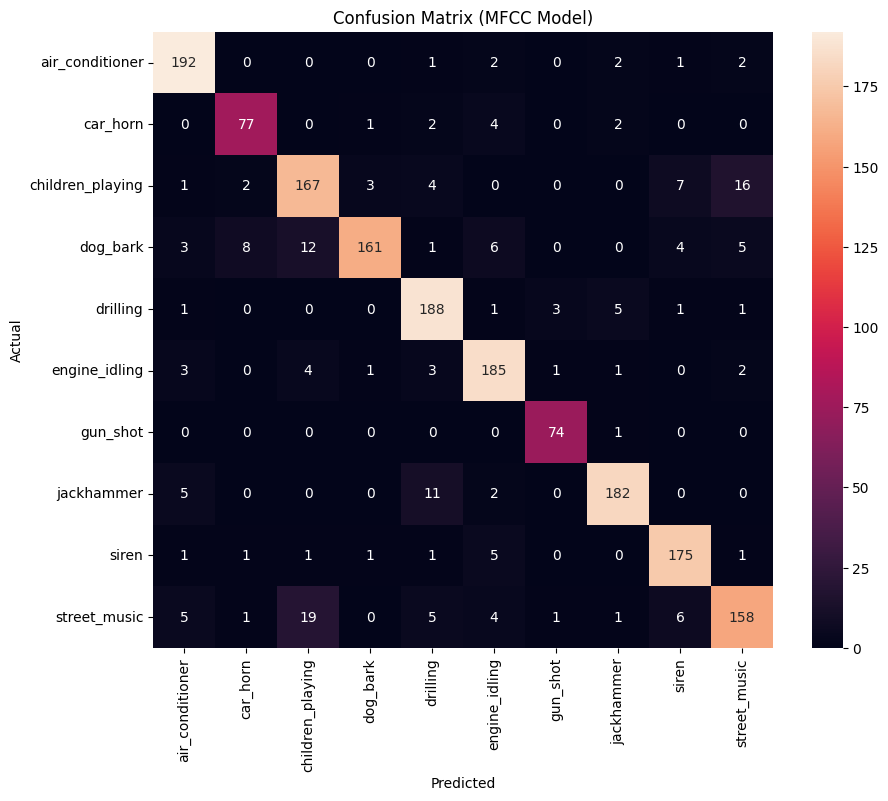

In [43]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (MFCC Model)")
plt.show()

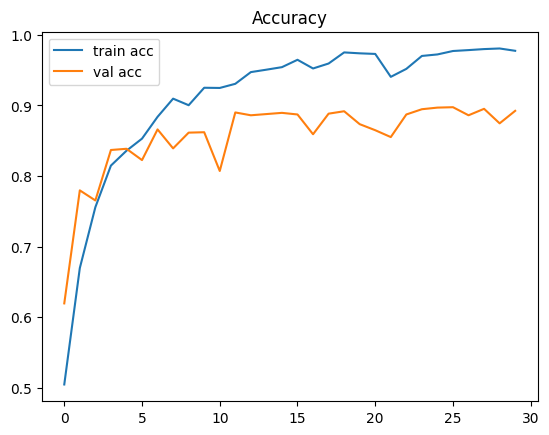

In [44]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

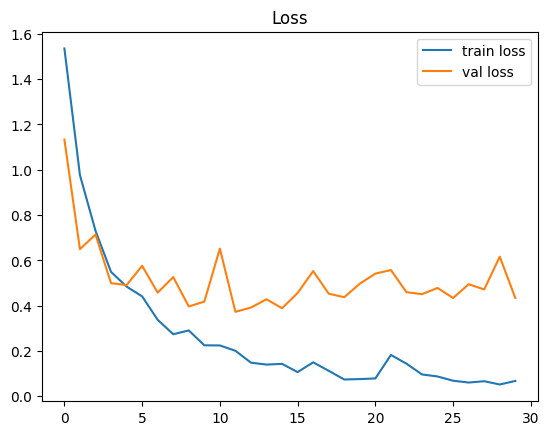

In [45]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()